In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_imgs, train_labels), (test_imgs, test_labels) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [3]:
train_imgs = train_imgs / 255.0
test_imgs = test_imgs / 255.0

In [4]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
model.fit(train_imgs, train_labels, epochs=10)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_imgs, test_labels)
print('Test accuracy:', test_acc)


Epoch 1/10


1875/1875 [==============================] - 21s 9ms/step - loss: 0.4992 - accuracy: 0.8257
Epoch 2/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.3749 - accuracy: 0.8655
Epoch 3/10
1875/1875 [==============================] - 13s 7ms/step - loss: 0.3352 - accuracy: 0.8776
Epoch 4/10
1875/1875 [==============================] - 16s 9ms/step - loss: 0.3119 - accuracy: 0.8838
Epoch 5/10
1875/1875 [==============================] - 31s 17ms/step - loss: 0.2950 - accuracy: 0.8912
Epoch 6/10
1875/1875 [==============================] - 42s 22ms/step - loss: 0.2816 - accuracy: 0.8959
Epoch 7/10
1875/1875 [==============================] - 29s 15ms/step - loss: 0.2681 - accuracy: 0.9001
Epoch 8/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.2595 - accuracy: 0.9034
Epoch 9/10
1875/1875 [==============================] - 16s 8ms/step - loss: 0.2469 - accuracy: 0.9079
Epoch 10/10
313/313 [==============================] - 3s 6ms/step 

In [8]:
predictions = model.predict(test_imgs)
predicted_labels = np.argmax(predictions, axis=1)

313/313 [==============================] - 2s 5ms/step


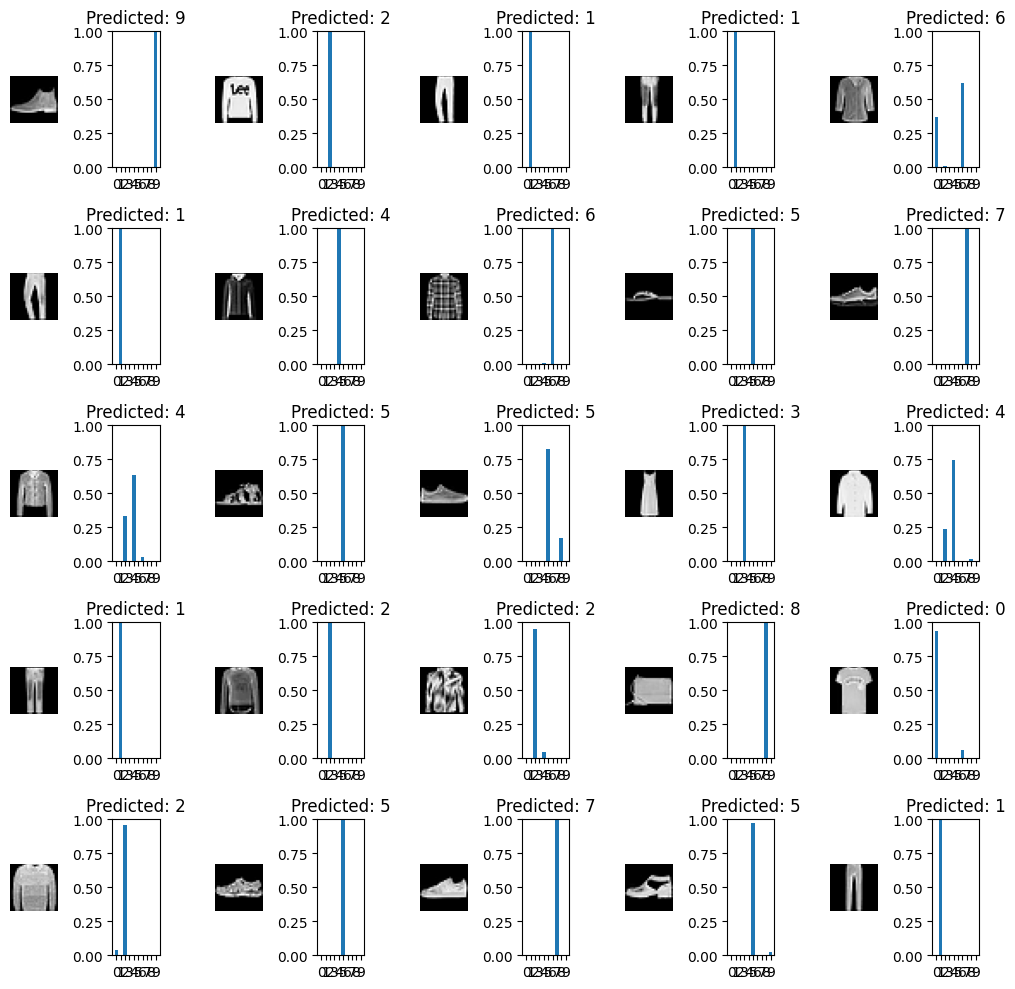

In [10]:
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols

plt.figure(figsize=(2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plt.imshow(test_imgs[i], cmap='gray')
    plt.axis('off')

    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plt.bar(range(10), predictions[i])
    plt.xticks(range(10))
    plt.ylim([0, 1])
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.tight_layout()

plt.show()